In [1]:
import sys
sys.path.append("..")

import pandas as pd

from torch.utils.data import DataLoader
from model_zoo import get_model
from dataset_zoo import VG_Relation, VG_Attribution, COCO_Order, Flickr30k_Order

In [2]:
# Please put your data root directory below. We'll download VG-Relation and VG-Attribution images here. 
# Will be a 1GB zip file (a subset of GQA).
root_dir="~/.cache" 


In [3]:
model, preprocess = get_model(model_name="openai-clip:ViT-B/32", device="cpu", root_dir=root_dir)

In [4]:
# Get the VG-R dataset
vgr_dataset = VG_Relation(image_preprocess=preprocess, download=False, root_dir=root_dir)
vgr_dataset.dataset = vgr_dataset.dataset[:]
vgr_dataset.all_relations = vgr_dataset.all_relations[:]
vgr_loader = DataLoader(vgr_dataset, batch_size=1, shuffle=False)

print(len(vgr_dataset))

23937


In [5]:
print(vgr_dataset.all_relations[:5])
# print(vgr_dataset.dataset[:5])

['to the left of', 'to the left of', 'wearing', 'on', 'to the right of']


In [6]:
import numpy as np
vgr_output = pd.read_csv("vgr_results.csv", index_col=0)
print(vgr_output.columns)
symmetric = ['adjusting', 'attached to', 'between', 'bigger than', 'biting', 'boarding', 'brushing', 'chewing', 'cleaning', 'climbing', 'close to', 'coming from', 'coming out of', 'contain', 'crossing', 'dragging', 'draped over', 'drinking', 'drinking from', 'driving', 'driving down', 'driving on', 'eating from', 'eating in', 'enclosing', 'exiting', 'facing', 'filled with', 'floating in', 'floating on', 'flying', 'flying above', 'flying in', 'flying over', 'flying through', 'full of', 'going down', 'going into', 'going through', 'grazing in', 'growing in', 'growing on', 'guiding', 'hanging from', 'hanging in', 'hanging off', 'hanging over', 'higher than', 'holding onto', 'hugging', 'in between', 'jumping off', 'jumping on', 'jumping over', 'kept in', 'larger than', 'leading', 'leaning over', 'leaving', 'licking', 'longer than', 'looking in', 'looking into', 'looking out', 'looking over', 'looking through', 'lying next to', 'lying on top of', 'making', 'mixed with', 'mounted on', 'moving', 'on the back of', 'on the edge of', 'on the front of', 'on the other side of', 'opening', 'painted on', 'parked at', 'parked beside', 'parked by', 'parked in', 'parked in front of', 'parked near', 'parked next to', 'perched on', 'petting', 'piled on', 'playing', 'playing in', 'playing on', 'playing with', 'pouring', 'reaching for', 'reading', 'reflected on', 'riding on', 'running in', 'running on', 'running through', 'seen through', 'sitting behind', 'sitting beside', 'sitting by', 'sitting in front of', 'sitting near', 'sitting next to', 'sitting under', 'skiing down', 'skiing on', 'sleeping in', 'sleeping on', 'smiling at', 'sniffing', 'splashing', 'sprinkled on', 'stacked on', 'standing against', 'standing around', 'standing behind', 'standing beside', 'standing in front of', 'standing near', 'standing next to', 'staring at', 'stuck in', 'surrounding', 'swimming in', 'swinging', 'talking to', 'topped with', 'touching', 'traveling down', 'traveling on', 'tying', 'typing on', 'underneath', 'wading in', 'waiting for', 'walking across', 'walking by', 'walking down', 'walking next to', 'walking through', 'working in', 'working on', 'worn on', 'wrapped around', 'wrapped in', 'by', 'of', 'near', 'next to', 'with', 'beside', 'on the side of', 'around']
not_symmetric = ~np.isin(vgr_dataset.all_relations, symmetric)
vgr_output = vgr_output.loc[not_symmetric]
print(not_symmetric.sum())
print(vgr_output.shape)
not_symmetric_indices = np.where(not_symmetric)[0]
vgr_dataset.dataset = [vgr_dataset.dataset[i] for i in not_symmetric_indices]
vgr_dataset.all_relations = [vgr_dataset.all_relations[i] for i in not_symmetric_indices]


print(len(vgr_dataset))
vgr_loader = DataLoader(vgr_dataset, batch_size=1, shuffle=False)

Index(['image_score_correct_score', 'image_score_incorrect_score',
       'no_image_correct_score', 'no_image_incorrect_score', 'image_correct',
       'no_image_correct', 'probability_increase'],
      dtype='object')
21944
(21944, 7)
21944


In [7]:
print(np.unique(vgr_dataset.all_relations))

['above' 'at' 'behind' 'below' 'beneath' 'carrying' 'covered by'
 'covered in' 'covered with' 'covering' 'cutting' 'eating' 'feeding'
 'grazing on' 'hanging on' 'holding' 'in' 'in front of' 'inside'
 'leaning against' 'leaning on' 'looking at' 'lying in' 'lying on' 'on'
 'on top of' 'parked on' 'pulled by' 'pulling' 'reflected in' 'resting on'
 'riding' 'sitting at' 'sitting in' 'sitting on' 'sitting on top of'
 'standing by' 'standing in' 'standing on' 'surrounded by'
 'to the left of' 'to the right of' 'under' 'using' 'walking in'
 'walking on' 'watching' 'wearing']


In [8]:
import torchvision.transforms as T
normalize = T.Normalize(
        mean=[-m / s for m, s in zip([0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225])],
        std=[1/s for s in [0.229, 0.224, 0.225]]
    )

to_pil = T.ToPILImage()


In [9]:
import numpy as np
# Compute the scores for each test case

# vgr_output 


In [10]:
biggest_increases = vgr_output["probability_increase"].argsort()[::-1][:10].values
print(biggest_increases)

[ 1070  9874 19463  9872 16652  8212 16719  7565  4487 18207]


In [11]:
import PIL
import matplotlib.pyplot as plt
#print(vgr_dataset[0])
for idx in biggest_increases:
    break
    vgr_dataset[0]["image_options"][0].shape
    print(vgr_dataset[idx]["caption_options"])
    image = normalize(vgr_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.show()

In [12]:
# Get the VG-A dataset
vga_dataset = VG_Attribution(image_preprocess=preprocess, download=False, root_dir=root_dir)
vga_dataset.dataset = vga_dataset.dataset[:]
vga_dataset.all_attributes = vga_dataset.all_attributes[:]

vga_loader = DataLoader(vga_dataset, batch_size=1, shuffle=False)
# Compute the scores for each test case


In [13]:

vga_output = pd.read_csv("vga_results.csv", index_col=0)
print(vga_output.columns)
vga_results_with_images = pd.read_csv(f"vga_results_with_image.csv", index_col=0)
print(vga_results_with_images.columns)

# shapes
print(vga_output.shape)
print(vga_results_with_images.shape)

Index(['image_score_correct_score', 'image_score_incorrect_score',
       'no_image_correct_score', 'no_image_incorrect_score', 'image_correct',
       'no_image_correct', 'probability_increase'],
      dtype='object')
Index(['Accuracy', 'Count', 'Dataset'], dtype='object')
(28748, 7)
(117, 3)


In [14]:
vga_easy = vga_output["no_image_correct"].values
vgr_easy = vgr_output["no_image_correct"].values

In [15]:
clip_vga_scores = pd.read_csv(f"clip_vga_scores.csv")
clip_vgr_scores = pd.read_csv(f"clip_vgr_scores.csv")[not_symmetric]
print(clip_vga_scores.shape)
print(clip_vgr_scores.shape)
clip_vga_correct = clip_vga_scores.iloc[:, 1] > clip_vga_scores.iloc[:, 0]
clip_vgr_correct = clip_vgr_scores.iloc[:, 1] > clip_vgr_scores.iloc[:, 0]

print(f"clip vga accuracy: {clip_vga_correct.mean()}")
print(f"clip vgr accuracy: {clip_vgr_correct.mean()}")

clip_acc_vgr_easy = clip_vgr_correct[vgr_easy]
clip_acc_vga_easy = clip_vga_correct[vga_easy]
clip_acc_vgr_hard = clip_vgr_correct[~vgr_easy]
clip_acc_vga_hard = clip_vga_correct[~vga_easy]

print(f"clip vga easy accuracy: {clip_acc_vga_easy.mean()}")
print(f"clip vgr easy accuracy: {clip_acc_vgr_easy.mean()}")

print(f"clip vga hard accuracy: {clip_acc_vga_hard.mean()}")
print(f"clip vgr hard accuracy: {clip_acc_vgr_hard.mean()}")


(28748, 2)
(21944, 2)
clip vga accuracy: 0.6094336997356338
clip vgr accuracy: 0.5071090047393365
clip vga easy accuracy: 0.620424843939462
clip vgr easy accuracy: 0.5117529081427998
clip vga hard accuracy: 0.5716710384199969
clip vgr hard accuracy: 0.5010022154235679


In [ ]:
# histogram with accuracies for overall, easy, hard in 4 cases: Clip on vgr, clip on vga, Neg Clip on vga, Neg clip on vgr

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

plt.figure(figsize=(10, 6))


In [ ]:

neg_clip_vga_scores = pd.read_csv(f"neg_clip_vga_scores.csv")
neg_clip_vgr_scores = pd.read_csv(f"neg_clip_vgr_scores.csv")[not_symmetric]
print(neg_clip_vga_scores.shape)
print(neg_clip_vgr_scores.shape)
neg_clip_vga_correct = neg_clip_vga_scores.iloc[:, 1] > neg_clip_vga_scores.iloc[:, 0]
neg_clip_vgr_correct = neg_clip_vgr_scores.iloc[:, 1] > neg_clip_vgr_scores.iloc[:, 0]

print(f"neg_clip vga accuracy: {neg_clip_vga_correct.mean()}")
print(f"neg_clip vgr accuracy: {neg_clip_vgr_correct.mean()}")

neg_clip_acc_vgr_easy = neg_clip_vgr_correct[vgr_easy]
neg_clip_acc_vga_easy = neg_clip_vga_correct[vga_easy]
neg_clip_acc_vgr_hard = neg_clip_vgr_correct[~vgr_easy]
neg_clip_acc_vga_hard = neg_clip_vga_correct[~vga_easy]

print(f"neg_clip vga easy accuracy: {neg_clip_acc_vga_easy.mean()}")
print(f"neg_clip vgr easy accuracy: {neg_clip_acc_vgr_easy.mean()}")

print(f"neg_clip vga hard accuracy: {neg_clip_acc_vga_hard.mean()}")
print(f"neg_clip vgr hard accuracy: {neg_clip_acc_vgr_hard.mean()}")


(28748, 2)
(21944, 2)
neg_clip vga accuracy: 0.7087101711423404
neg_clip vgr accuracy: 0.5864473204520598
neg_clip vga easy accuracy: 0.740467957066511
neg_clip vgr easy accuracy: 0.6859205776173285
neg_clip vga hard accuracy: 0.5995988273414596
neg_clip vgr hard accuracy: 0.45563878046207407


In [23]:
qwen_vga_corrects = vga_output["image_correct"].values
qwen_vgr_corrects = vgr_output["image_correct"].values

qwen_vga_easy = qwen_vga_corrects[vga_easy]
qwen_vgr_easy = qwen_vgr_corrects[vgr_easy]
qwen_vga_hard = qwen_vga_corrects[~vga_easy]
qwen_vgr_hard = qwen_vgr_corrects[~vgr_easy]

print(f"qwen vga accuracy: {qwen_vga_corrects.mean()}")
print(f"qwen vgr accuracy: {qwen_vgr_corrects.mean()}")
print(f"qwen vga easy accuracy: {qwen_vga_easy.mean()}")
print(f"qwen vgr easy accuracy: {qwen_vgr_easy.mean()}")
print(f"qwen vga hard accuracy: {qwen_vga_hard.mean()}")
print(f"qwen vgr hard accuracy: {qwen_vgr_hard.mean()}")

qwen vga accuracy: 0.9127591484625017
qwen vgr accuracy: 0.7110371855632519
qwen vga easy accuracy: 0.9488480711366596
qwen vgr easy accuracy: 0.8401925391095066
qwen vga hard accuracy: 0.7887671655608702
qwen vgr hard accuracy: 0.5411963287266589


In [ ]:
print(
        neg_clip_acc_vgr_easy.mean())

print(
[
        clip_vgr_correct.mean(),
        clip_acc_vgr_hard.mean(),
        clip_acc_vgr_easy.mean(),
        neg_clip_vgr_correct.mean(),
        neg_clip_acc_vgr_hard.mean(), 
        neg_clip_acc_vgr_easy.mean(), 
        qwen_vgr_corrects.mean(), 
        qwen_vgr_hard.mean(), 
        qwen_vgr_easy.mean()]
)

0.6859205776173285
[np.float64(0.5071090047393365), np.float64(0.5010022154235679), np.float64(0.5117529081427998), np.float64(0.5864473204520598), np.float64(0.45563878046207407), np.float64(0.6859205776173285), np.float64(0.7110371855632519), np.float64(0.5411963287266589), np.float64(0.8401925391095066)]


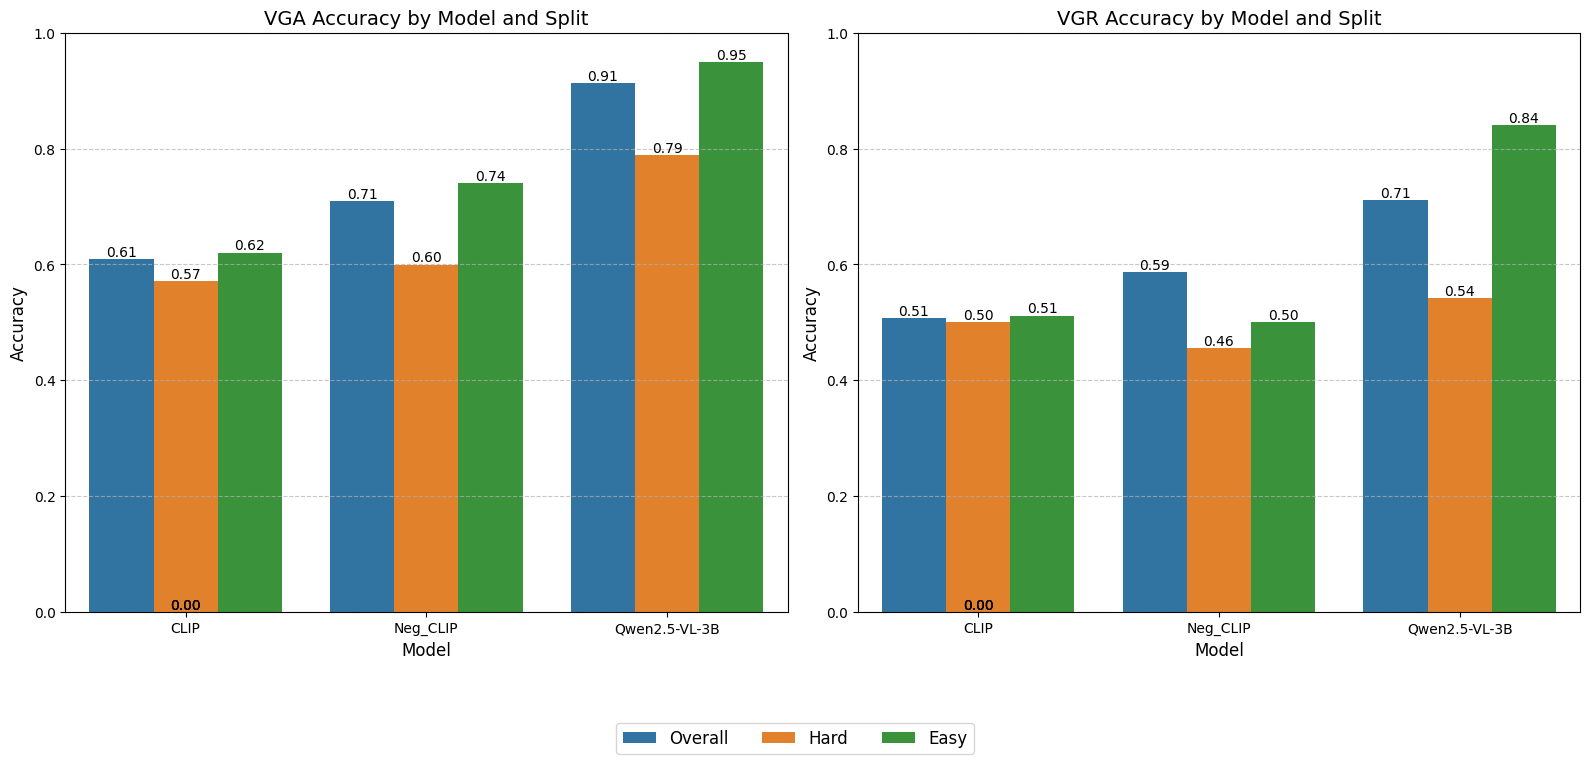

In [48]:
import seaborn as sns

vga_data = {
    'Model': ['CLIP', 'CLIP', 'CLIP', 'Neg_CLIP', 'Neg_CLIP', 'Neg_CLIP', 'Qwen2.5-VL-3B', 'Qwen2.5-VL-3B', 'Qwen2.5-VL-3B'],
    'Split': ['Overall', 'Hard', 'Easy', 'Overall', 'Hard', 'Easy', 'Overall', 'Hard', 'Easy'],
    'Accuracy': [
        clip_vga_correct.mean(),
        clip_acc_vga_hard.mean(),
        clip_acc_vga_easy.mean(),
        neg_clip_vga_correct.mean(),
        neg_clip_acc_vga_hard.mean(), 
        neg_clip_acc_vga_easy.mean(), 
        qwen_vga_corrects.mean(), 
        qwen_vga_hard.mean(), 
        qwen_vga_easy.mean()]  # Example values
}

vgr_data = {
    'Model': ['CLIP', 'CLIP', 'CLIP', 'Neg_CLIP', 'Neg_CLIP', 'Neg_CLIP', 'Qwen2.5-VL-3B', 'Qwen2.5-VL-3B', 'Qwen2.5-VL-3B'],
    'Split': ['Overall', 'Hard', 'Easy', 'Overall', 'Hard', 'Easy', 'Overall', 'Hard', 'Easy'],
    'Accuracy': [
        clip_vgr_correct.mean(),
        clip_acc_vgr_hard.mean(),
        clip_acc_vgr_easy.mean(),
        neg_clip_vgr_correct.mean(),
        neg_clip_acc_vgr_hard.mean(), 
        0.5, # neg_clip_acc_vgr_easy.mean(), 
        qwen_vgr_corrects.mean(), 
        qwen_vgr_hard.mean(), 
        qwen_vgr_easy.mean()]  # Example values
}


# Create DataFrames
vga_df = pd.DataFrame(vga_data)
vgr_df = pd.DataFrame(vgr_data)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Set color palette for the splits
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green
sns.set_palette(colors)

# VGA plot

barplot1 = sns.barplot(x='Model', y='Accuracy', hue='Split', data=vga_df, ax=ax1)
ax1.set_title('VGA Accuracy by Model and Split', fontsize=14)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# VGR plot
barplot2 = sns.barplot(x='Model', y='Accuracy', hue='Split', data=vgr_df, ax=ax2)
ax2.set_title('VGR Accuracy by Model and Split', fontsize=14)
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add value annotations
for ax, barplot in [(ax1, barplot1), (ax2, barplot2)]:
    for p in barplot.patches:
        ax.annotate(f'{p.get_height():.2f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', fontsize=10, color='black',
                   xytext=(0, 5), textcoords='offset points')

# Add a single legend for both plots
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
          ncol=3, frameon=True, fontsize=12)

# Remove individual legends
ax1.get_legend().remove()
ax2.get_legend().remove()

plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Adjust layout to make room for the legend
plt.savefig('figures/accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [17]:
vga_biggest_increases = vga_output["probability_increase"].argsort()[:20].values
print(biggest_increases)
mean_increase = vga_output["probability_increase"].values
mean_increase = np.exp(np.mean(np.log(mean_increase)))
print(f"mean increase: {mean_increase}")

num_increases = (vga_output["probability_increase"] > 1).mean()
print(num_increases)

vga_switched = (~ vga_output["no_image_correct"] & vga_output["image_correct"])
vga_opposite = (vga_output["no_image_correct"] & ~ vga_output["image_correct"])

print(f"vga switched from incorrect to correct after seeing image {vga_switched.mean()*100}%")
print(f"vga switched from correct to incorrect after seeing image {vga_opposite.mean()*100}%")

vga_switched_idx = np.where(vga_switched)[0]
vga_opposite_idx = np.where(vga_opposite)[0]


[ 1070  9874 19463  9872 16652  8212 16719  7565  4487 18207]
mean increase: 23.36369099512748
0.7264157506609156
vga switched from incorrect to correct after seeing image 17.782106581327398%
vga switched from correct to incorrect after seeing image 3.962014748852094%


In [18]:
vgr_biggest_increases = vgr_output["probability_increase"].argsort()[:20].values
print(biggest_increases)

num_increases = (vgr_output["probability_increase"] > 1).mean()
print(num_increases)

mean_increase = vgr_output["probability_increase"].values
mean_increase = np.exp(np.mean(np.log(mean_increase)))
print(f"mean increase: {mean_increase}")

vgr_switched = (~ vgr_output["no_image_correct"] & vgr_output["image_correct"])
vgr_opposite = (vgr_output["no_image_correct"] & ~ vgr_output["image_correct"])

print(f"switched from incorrect to correct after seeing image {vgr_switched.mean()*100}%")
print(f"switched from correct to incorrect after seeing image {vgr_opposite.mean()*100}%")

vgr_switched_idx = np.where(vgr_switched)[0]
vgr_opposite_idx = np.where(vgr_opposite)[0]

[ 1070  9874 19463  9872 16652  8212 16719  7565  4487 18207]
0.6009387531899381
mean increase: 4.562158026046788
switched from incorrect to correct after seeing image 23.37768866204885%
switched from correct to incorrect after seeing image 9.07765220561429%


In [19]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Create the 'figures' directory if it doesn't exist
if not os.path.exists("figures/vgr"):
    os.makedirs("figures/vgr")

if not os.path.exists("figures/vga"):
    os.makedirs("figures/vga")

for idx in vgr_opposite_idx[:100]:
    vgr_dataset[0]["image_options"][0].shape
    image = normalize(vgr_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.title(f"{vgr_dataset[idx]['caption_options']}")
    # plt.show() # Removed plt.show()
    # plt.show() # Removed plt.show()
    plt.savefig(f"figures/vgr/vgr_wrong_switch_{idx}") # Changed path and removed .png
    plt.close()

for idx in vgr_switched_idx[:100]:
    vgr_dataset[0]["image_options"][0].shape
    image = normalize(vgr_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.title(f"{vgr_dataset[idx]['caption_options']}")
    # plt.show() # Removed plt.show()
    # plt.show() # Removed plt.show()
    plt.savefig(f"figures/vgr/vgr_correct_switch_{idx}") # Changed path and removed .png
    plt.close()

for idx in vgr_biggest_increases[:10]:
    vgr_dataset[0]["image_options"][0].shape
    image = normalize(vgr_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.title(f"{vgr_dataset[idx]['caption_options']}")
    # plt.show() # Removed plt.show()
    plt.savefig(f"figures/vgr/vgr_biggest_increase_{idx}") # Changed path and removed .png
    plt.close()

for idx in vga_opposite_idx[:10]:
    vga_dataset[0]["image_options"][0].shape
    image = normalize(vga_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.title(f"{vga_dataset[idx]['caption_options']}")
    # plt.show() # Removed plt.show()
    plt.savefig(f"figures/vga/vga_wrong_switch_{idx}") # Changed path and removed .png
    plt.close()

for idx in vga_switched_idx[:10]:
    vga_dataset[0]["image_options"][0].shape
    image = normalize(vga_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.title(f"{vga_dataset[idx]['caption_options']}")
    # plt.show() # Removed plt.show()
    plt.savefig(f"figures/vga/vga_correct_switch_{idx}") # Changed path and removed .png
    plt.close()

for idx in vga_biggest_increases[:10]:
    vga_dataset[0]["image_options"][0].shape
    image = normalize(vga_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.title(f"{vga_dataset[idx]['caption_options']}")
    # plt.show() # Removed plt.show()
    plt.savefig(f"figures/vga/vga_biggest_increase_{idx}") # Changed path and removed .png
    plt.close()


In [20]:
import PIL
import matplotlib.pyplot as plt
#print(vgr_dataset[0])
for idx in vga_biggest_increases:
    break
    vga_dataset[0]["image_options"][0].shape
    print(vga_dataset[idx]["caption_options"])
    print(f"correct score: {vga_output.iloc[idx]["image_score_correct_score"]}")
    print(f"probability increase: {vga_output.iloc[idx]["probability_increase"]}")

    image = normalize(vga_dataset[idx]["image_options"][0])
    image = to_pil(image)
    plt.imshow(image)
    plt.show()